# Lecture 9: Text Representation & Embeddings
### NLP Course 2027

---

## Learning Outcomes
- Understand the need for numerical text representation
- Apply Bag-of-Words and TF-IDF vectorization
- Train and use Word2Vec embeddings with gensim
- Visualize and reason about word vector spaces

**Primary References:** *Practical NLP* Ch.3 | *NLP with Transformers* Ch.2 (background)

## 1. From Text to Numbers

Machine learning models work with **numerical vectors**, not raw text. We need to convert:

```
'The cat sat'  →  [0.2, -0.5, 1.1, ..., 0.8]  (n-dimensional vector)
```

### Evolution of Text Representations
```
1990s–2010s   Sparse Representations
              Bag of Words: [0, 1, 0, 2, 1, ...]
              TF-IDF:       [0, 0.4, 0, 0.7, ...]
                             ↓ Many zeros, no semantics

2013–now      Dense Distributed Representations
              Word2Vec:  [-0.2, 0.5, 1.1, 0.3, ...] (300 dims)
              GloVe, FastText, BERT embeddings
                             ↓ Captures meaning, small & dense
```

In [5]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import numpy as np

docs = [
    'the cat sat on the mat',
    'the dog sat on the log',
    'the cat and the dog played together',
    'machine learning is fun and exciting',
    'natural language processing and machine learning'
]

# Bag of Words
cv = CountVectorizer()
bow_matrix = cv.fit_transform(docs)
print('Bag of Words matrix shape:', bow_matrix.shape)
print('Vocabulary size:', len(cv.vocabulary_))
print(f'Sample vocab: {list(cv.vocabulary_.items())[:10]}')
print()
print('BoW matrix (dense):')
print(bow_matrix.toarray())

Bag of Words matrix shape: (5, 18)
Vocabulary size: 18
Sample vocab: [('the', 16), ('cat', 1), ('sat', 15), ('on', 12), ('mat', 10), ('dog', 2), ('log', 8), ('and', 0), ('played', 13), ('together', 17)]

BoW matrix (dense):
[[0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 1 2 0]
 [0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 1 2 0]
 [1 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 2 1]
 [1 0 0 1 1 1 0 1 0 1 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 1 1 0 1 0 1 0 0 1 0 0 0]]


In [6]:
# TF-IDF
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(docs)
features = tfidf.get_feature_names_out()

import pandas as pd
df = pd.DataFrame(tfidf_matrix.toarray(), columns=features,
                  index=[f'doc{i+1}' for i in range(len(docs))])
print('TF-IDF Matrix:')
print(df.round(3))

TF-IDF Matrix:
        and    cat    dog  exciting    fun     is  language  learning    log  \
doc1  0.000  0.370  0.000     0.000  0.000  0.000     0.000      0.00  0.000   
doc2  0.000  0.000  0.370     0.000  0.000  0.000     0.000      0.00  0.459   
doc3  0.284  0.343  0.343     0.000  0.000  0.000     0.000      0.00  0.000   
doc4  0.307  0.000  0.000     0.459  0.459  0.459     0.000      0.37  0.000   
doc5  0.307  0.000  0.000     0.000  0.000  0.000     0.459      0.37  0.000   

      machine    mat  natural    on  played  processing   sat    the  together  
doc1     0.00  0.459    0.000  0.37   0.000       0.000  0.37  0.615     0.000  
doc2     0.00  0.000    0.000  0.37   0.000       0.000  0.37  0.615     0.000  
doc3     0.00  0.000    0.000  0.00   0.425       0.000  0.00  0.569     0.425  
doc4     0.37  0.000    0.000  0.00   0.000       0.000  0.00  0.000     0.000  
doc5     0.37  0.000    0.459  0.00   0.000       0.459  0.00  0.000     0.000  


In [7]:
# Cosine similarity between documents
from sklearn.metrics.pairwise import cosine_similarity

sim_matrix = cosine_similarity(tfidf_matrix)
print('Document similarity matrix:')
df_sim = pd.DataFrame(sim_matrix.round(3),
                       index=[f'doc{i+1}' for i in range(len(docs))],
                       columns=[f'doc{i+1}' for i in range(len(docs))])
print(df_sim)
print()
print('Most similar to doc5 (NLP+ML):')
sims = sorted(enumerate(sim_matrix[4]), key=lambda x: x[1], reverse=True)
for idx, score in sims[1:]:
    print(f'  doc{idx+1}: {score:.3f} - {docs[idx]}')

Document similarity matrix:
       doc1   doc2   doc3   doc4   doc5
doc1  1.000  0.652  0.477  0.000  0.000
doc2  0.652  1.000  0.477  0.000  0.000
doc3  0.477  0.477  1.000  0.087  0.087
doc4  0.000  0.000  0.087  1.000  0.368
doc5  0.000  0.000  0.087  0.368  1.000

Most similar to doc5 (NLP+ML):
  doc4: 0.368 - machine learning is fun and exciting
  doc3: 0.087 - the cat and the dog played together
  doc1: 0.000 - the cat sat on the mat
  doc2: 0.000 - the dog sat on the log


## 2. Limitations of Sparse Representations

| Problem | Example |
|---------|--------|
| **Sparsity** | 90%+ zeros for large vocab |
| **No semantics** | 'king' and 'queen' have same distance as 'king' and 'pizza' |
| **High dimensionality** | vocab size = 50k–500k features |
| **Out-of-vocab** | New words unseen in training have no representation |
| **Word order lost** | 'dog bites man' = 'man bites dog' |

**Solution**: Dense, distributed word representations.

## 3. Word Embeddings

**Distributional Hypothesis** (Harris, 1954):
> *"You shall know a word by the company it keeps."*

Words that appear in similar contexts have similar meanings.

```
Context window (size=2):
  'The king rules the kingdom'
         ↑
  Window around 'king': ['The', 'rules', 'the']

Words that share similar contexts → similar vectors:
  king ≈ queen (both appear near: crowned, rules, royal)
  cat ≈ dog (both appear near: pet, animal, fur)
```

### Word2Vec Architectures
```
CBOW (Continuous Bag of Words):
  [The, brown, jumps, over] → predict → [fox]

Skip-gram:
  [fox] → predict → [The, brown, jumps, over]
```

In [8]:
# Train Word2Vec with gensim
# !pip install gensim

import gensim
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import gutenberg
import nltk

nltk.download('gutenberg', quiet=True)
nltk.download('punkt', quiet=True)

# Use Emma by Jane Austen as training corpus
print('Loading corpus...')
sentences = [word_tokenize(s.lower()) for s in sent_tokenize(gutenberg.raw('austen-emma.txt'))]
print(f'Sentences: {len(sentences)}')
print(f'Sample: {sentences[0][:10]}')

# Train Word2Vec
model = Word2Vec(
    sentences,
    vector_size=100,   # embedding dimensions
    window=5,          # context window size
    min_count=5,       # ignore words with freq < min_count
    workers=4,         # parallel workers
    epochs=10,
    sg=0               # 0=CBOW, 1=Skip-gram
)
print(f'\nVocabulary size: {len(model.wv)}')
print(f'Vector dimensions: {model.vector_size}')

Loading corpus...
Sentences: 7493
Sample: ['[', 'emma', 'by', 'jane', 'austen', '1816', ']', 'volume', 'i', 'chapter']

Vocabulary size: 2335
Vector dimensions: 100


In [9]:
# Exploring word vectors
# Most similar words
print('Words similar to "love":')
for word, score in model.wv.most_similar('love', topn=8):
    print(f'  {word:15s} {score:.4f}')

print('\nWords similar to "house":')
for word, score in model.wv.most_similar('house', topn=8):
    print(f'  {word:15s} {score:.4f}')

Words similar to "love":
  favour          0.8319
  conduct         0.8101
  fortune         0.7965
  praise          0.7959
  interference    0.7958
  suit            0.7911
  delicacy        0.7902
  memory          0.7891

Words similar to "house":
  appearance      0.9146
  part            0.9130
  silence         0.9036
  end             0.9034
  spirits         0.9030
  room            0.9025
  evening         0.9017
  table           0.8991


In [10]:
# Word arithmetic: analogies
# king - man + woman = queen?
print('Word analogies:')

# With Jane Austen, we might not have 'king' but let's try
try:
    result = model.wv.most_similar(positive=['woman', 'mr'], negative=['man'], topn=3)
    print('woman + mr - man =', result)
except KeyError as e:
    print(f'Word not in vocab: {e}')

# Similarity between word pairs
pairs = [
    ('love', 'hate'), ('love', 'affection'), ('man', 'woman'),
    ('house', 'home'), ('good', 'bad'), ('good', 'excellent')
]
print('\nWord pair similarities:')
for w1, w2 in pairs:
    try:
        sim = model.wv.similarity(w1, w2)
        print(f'  {w1:12s} vs {w2:12s}: {sim:.4f}')
    except KeyError:
        print(f'  {w1} or {w2} not in vocab')

Word analogies:
woman + mr - man = [('yorkshire', 0.8557682037353516), ('age', 0.8303676247596741), ('mrs', 0.8278326988220215)]

Word pair similarities:
  love or hate not in vocab
  love         vs affection   : 0.6839
  man          vs woman       : 0.9107
  house        vs home        : 0.5911
  good         vs bad         : 0.8006
  good         vs excellent   : 0.6820


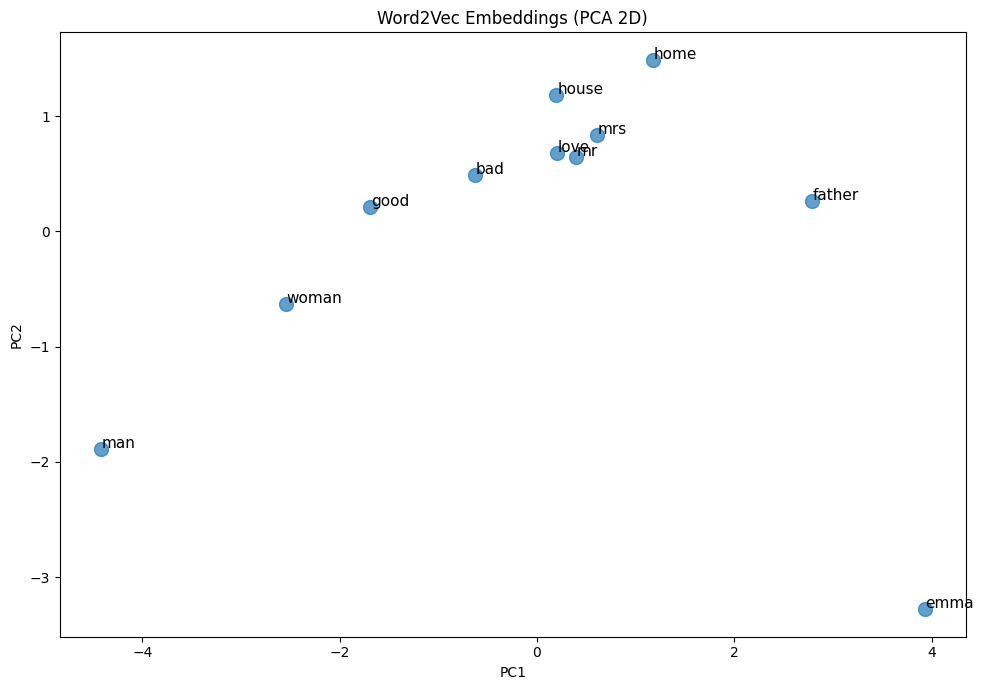

In [11]:
# Visualize word embeddings with PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Get vectors for common words that exist in our vocab
words_to_plot = [
    'love', 'hate', 'good', 'bad', 'house', 'home',
    'man', 'woman', 'mr', 'mrs', 'emma', 'father'
]

valid_words = [w for w in words_to_plot if w in model.wv]
vectors = np.array([model.wv[w] for w in valid_words])

# PCA to 2D
pca = PCA(n_components=2)
coords = pca.fit_transform(vectors)

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(coords[:, 0], coords[:, 1], alpha=0.7, s=100)
for i, word in enumerate(valid_words):
    ax.annotate(word, (coords[i, 0]+0.01, coords[i, 1]+0.01), fontsize=11)
ax.set_title('Word2Vec Embeddings (PCA 2D)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.tight_layout()
plt.show()

In [12]:
# Using pre-trained embeddings (GloVe via gensim)
# Download: https://nlp.stanford.edu/projects/glove/

# Concept demo with gensim's KeyedVectors
print('Pre-trained embeddings (concept):')
print()
print('GloVe vectors are trained on 6B Wikipedia/Gigaword tokens')
print('FastText vectors include subword information (handles typos/rare words)')
print('Both available via gensim.downloader:')
print()
print('  import gensim.downloader')
print('  glove = gensim.downloader.load("glove-wiki-gigaword-100")')
print('  glove.most_similar("king")')
print()
# If you have them downloaded:
# import gensim.downloader
# glove = gensim.downloader.load('glove-wiki-gigaword-50')
# print(glove.most_similar('king'))

Pre-trained embeddings (concept):

GloVe vectors are trained on 6B Wikipedia/Gigaword tokens
FastText vectors include subword information (handles typos/rare words)
Both available via gensim.downloader:

  import gensim.downloader
  glove = gensim.downloader.load("glove-wiki-gigaword-100")
  glove.most_similar("king")



## 4. Types of Word Embeddings

| Method | Training | Strength | Weakness |
|--------|----------|----------|----------|
| Word2Vec (CBOW) | Local window | Fast, good semantics | Fixed vocab |
| Word2Vec (Skip-gram) | Local window | Better for rare words | Slower |
| GloVe | Global co-occurrence | Global + local stats | Fixed vocab |
| FastText | Subword | Handles OOV, typos | Larger model |
| ELMo | Bidirectional LM | Contextual | Slower |
| BERT | Masked LM | Best contextual | Very large |

**Contextual embeddings** (ELMo, BERT) produce different vectors for the same word in different contexts:
- 'bank' in 'river bank' vs 'blood bank' → different BERT vectors

## Practice Exercises

See **`Lecture-09-Homework.ipynb`** for the practice exercises accompanying this lecture.

## Summary

| Representation | Type | Captures Semantics | Handles OOV |
|----------------|------|--------------------|-------------|
| Bag of Words | Sparse | No | No |
| TF-IDF | Sparse | Partial | No |
| Word2Vec/GloVe | Dense | Yes | No |
| FastText | Dense | Yes | Yes (subword) |
| BERT/contextual | Dense, contextual | Yes | Yes (subword) |

**Next Lecture**: Deep Learning for Text Classification — LSTMs, CNNs, neural architectures.

---
*Book references: Practical NLP Ch.3 | NLP with Transformers Ch.2*

---
**Author: Lei Wu | © 2026 Lei Wu. All rights reserved. Unauthorized use is prohibited.**